In [39]:
"""
3x2pt Fisher for LSST
"""

'\n3x2pt Fisher for LSST\n'

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
import numpy as np, sys, os, scipy as sc
import tools_nx2pt, misc

from pylab import *
cmap = cm.RdYlBu
rcParams['figure.dpi'] = 150


In [42]:
import copy
"""
lsst_param_dict = {'a_s': 3.044, 'h': 0.6736, 'n_s': 0.9649, 'omega_c_h2': 0.1200,  'omega_b_h2': 0.02237, 'tau': 0.0544, 'w_0': -1.0, 'w_a': 0.0}
lsst_param_dict_more = {'omega_m': 0.3156, 'omega_b': 0.0491685, 'sigma_8': 0.831, 'a_0': 5.92, 'beta': 1.1, 'eta_low_z': -0.47, 'eta_high_z': 0.0, 'b_1': 1.2509509, 'b_2': 1.37274743, 'b_3': 1.50062059, 'b_4': 1.64802316, 'b_5': 1.7995586, 'phi_0_star': 0.0111, 'p': -1.15, 'm_0_star': -20.34, 'q': 1.2, 'alpha': -0.57}
lsst_param_dict = lsst_param_dict | lsst_param_dict_more
#lsst_param_dict['As'] = lsst_param_dict['a_s']
#lsst_param_dict['omch2'] = lsst_param_dict['omega_c_h2']
#lsst_param_dict['ombh2'] = lsst_param_dict['omega_b_h2']
lsst_param_dict['ns'] = lsst_param_dict['n_s']
lsst_param_dict['sigma8'] = lsst_param_dict['sigma_8']
lsst_param_dict['w0'] = lsst_param_dict['w_0']
lsst_param_dict['wa'] = lsst_param_dict['w_a']
"""
lsst_param_dict = {'omegam': 0.3156, 'omegab': 0.0491685, 'h': 0.6736, 'ns': 0.9649, 'sigma8': 0.831, 'tau': 0.0544, 'w0': -1.0, 'wa': 0.0, 'mnu': 0.06, 
                   'a_0': 5.92, 'beta': 1.1, 'eta_low_z': -0.47, 'eta_high_z': 0.0, 
                   'b_1': 1.2509509, 'b_2': 1.37274743, 'b_3': 1.50062059, 'b_4': 1.64802316, 'b_5': 1.7995586, 
                   'phi_0_star': 0.0111, 'p': -1.15, 'm_0_star': -20.34, 'q': 1.2, 'alpha': -0.57,
                  }
lsst_param_dict_sr = copy.deepcopy(lsst_param_dict)
lsst_param_dict_sr['a_ia'] = 1.8
lsst_param_dict_sr['logAs'] = 3.044
lsst_param_dict_sr['As'] = np.exp(lsst_param_dict_sr['logAs'])/1e10
lsst_param_dict_sr['eta_ia'] = 0.6
lsst_param_dict_sr['fnl_loc'] = 0.1
lsst_param_dict_sr['kmax'] = 0.2 ##1. ###0.3

lsst_year = 'y1'
lsst_param_set_dict = {
                    'y1': ['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h', 'b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'a_0', 'beta', 'eta_low_z', 'eta_high_z'],
                    'y10': ['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h', 'b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'b_6', 'b_7', 'b_8', 'b_9', 'b_10', 'a_0', 'beta', 'eta_low_z', 'eta_high_z'],
                    }

lsst_param_set_dict_sr = {
                    'y1': ['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h', 'mnu', 'b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'a_ia', 'eta_ia', 'fnl_loc'],
                    }

lsst_fsky_dic = {'cl_s_s': 0.4, 'cl_g_s': 0.4, 'cl_g_g': 0.4, 'cl_k_k': 0.4, 'cl_k_g': 0.4, 'cl_k_s': 0.4}
###lsst_fsky_dic = {'cl_s_s': 0.6560155555555556, 'cl_g_s': 0.6560155555555556, 'cl_g_g': 0.6560155555555556}

lsst_params = lsst_param_set_dict[lsst_year]

lsst_params_sr = lsst_param_set_dict_sr[lsst_year]

lsst_cosmo_params = ['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h', 'mnu']
lsst_nuisance_params = ['b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'a_0', 'beta', 'eta_low_z', 'eta_high_z']
lsst_nuisance_params_sr = ['b_1', 'b_2', 'b_3', 'b_4', 'b_5', 'a_ia', 'eta_ia']


In [47]:
experiment = 'lsst_y1_source'
zbin_mid = (0.5, 1.0)
kpivot, kmin, kmax, kdelta = 0.05, 1e-3, 1., 100
delta_c = 1.686
zarr, dndz_bin, bias_model, exp_specs_dic = tools_nx2pt.get_dngal_dz_photoz(experiment, zbin_mid, cosmo_param_dict = lsst_param_dict_sr)
sys.exit()
#tools_nx2pt.get_scale_dependent_bias(lsst_param_dict_sr, zarr, bias_model, exp_specs_dic)

import pyccl as ccl
cosmo_param_dict, cosmo = tools_nx2pt.process_cosmo_param_dict_and_set_cosmo(lsst_param_dict_sr)
scale_fac_arr = 1/(1+zarr)
Dz = ccl.growth_factor(cosmo, scale_fac_arr)
karr = np.geomspace(kmin, kmax, kdelta)
pk_lin = ccl.linear_matter_power(cosmo, karr, scale_fac_arr)

#p_primordial = (2 * np.pi**2 / karr**3) * lsst_param_dict_sr['As'] * (karr / kpivot)**(lsst_param_dict_sr['ns'] - 1.0)
transfer_k = (1./Dz[:,np.newaxis]) * np.sqrt(pk_lin[np.newaxis, :] / p_primordial)[0]

t1 = (bias_model-1) * cosmo_param_dict['fnl_loc'] * delta_c
t2 = 3 * cosmo_param_dict['omegam'] * (100*cosmo_param_dict['h'])**2.
t3 = karr**2. * transfer_k * Dz[:,np.newaxis]
scale_dep_bias_model = (t1[:,np.newaxis] * t2)/t3

ax = subplot(111, xscale = 'log')
color_arr = [cm.RdYlBu_r(int(d)) for d in np.linspace(0, 255, len(zarr))]
for zcntr in range(len(zarr)):
    inds = np.where(karr>1e-4)[0]
    plot(karr[inds], scale_dep_bias_model[zcntr, inds], color = color_arr[zcntr])
show()

SystemExit: 

/cvmfs/spt.opensciencegrid.org/py3-v4/RHEL_9_x86_64/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3465: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [34]:
pk_matter = np.zeros((len(zarr), len(karr)))
for i, a in enumerate(scale_fac_arr):
    pk_matter[i, :] = ccl.nonlin_matter_power(cosmo, karr, a) # Or ccl.linear_matter_power
print(pk_matter.shape)

pk_galaxy_matrix = (scale_dep_bias_model ** 2) * pk_matter

pk_gg = ccl.Pk2D(
    a_arr=scale_fac_arr[::-1], 
    lk_arr=np.log(karr), 
    pk_arr=pk_matter, 
    is_logp=False  # pk_arr holds raw P(k) values, not log(P(k))
)

pk_gg_custom = ccl.Pk2D(
    a_arr=scale_fac_arr[::-1], 
    lk_arr=np.log(karr), 
    pk_arr=pk_galaxy_matrix, 
    is_logp=False  # pk_arr holds raw P(k) values, not log(P(k))
)

dndz = (zarr, np.exp(-((zarr - 0.7) / 0.1)**2))
tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=dndz, bias=(zarr, np.ones_like(zarr)))

cls = ccl.angular_cl(cosmo, tracer, tracer, ell, p_of_k_a=pk_gg)
cls_v2 = ccl.angular_cl(cosmo, tracer, tracer, ell, p_of_k_a=pk_gg_custom)
clf()
ax = subplot(111, yscale = 'log')
plot(ell,cls)
plot(ell,cls_v2)
show()

NameError: name 'zarr' is not defined

In [35]:
# Obtain own data vectors for LSST
zbinwidth = 0.5
experiment = 'lsst_y1'
ell = np.geomspace(2, 2000, 20)

ell, zbin_arr, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, data_vector_dic, noise_vector_dic, full_cov_mat_dic = tools_nx2pt.get_nx2pt_data_vectors_and_cov(experiment, zbinwidth, ell = ell, cosmo_param_dict = lsst_param_dict_sr, get_cmb_lensing = False, obtain_cov = True, fsky_dic = lsst_fsky_dic)
####ell, zbin_arr_sr, data_vector_dic_sr = tools_nx2pt.get_nx2pt_data_vectors_and_cov(dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, ell = ell, cosmo_param_dict = lsst_param_dict)
print(zbin_arr); ##sys.exit()

if (0):
    import scipy.linalg
    ellind_to_plot = 2 #18 #0
    to_plot = np.copy( full_cov_mat_dic[ellind_to_plot] )
    full_inv_cov_mat = linalg.pinv(to_plot)
    to_plot[to_plot==0.] = None
    
    imshow(to_plot); colorbar(); show()

    to_plot = np.copy(full_inv_cov_mat)
    to_plot[to_plot==0.] = None
    imshow(to_plot); colorbar(); show()
    sys.exit()

#get derivatives
print('\n#get derivatives\n')
derivative_vector_dic = tools_nx2pt.get_nx2pt_derivatives(experiment, zbinwidth, lsst_params_sr, lsst_param_dict_sr, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, ell = ell, data_vector_dic = data_vector_dic)

#get Fisher matrix
obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s']
lsst_fisher_mat = tools_nx2pt.get_nx2pt_fisher(ell, lsst_params_sr, derivative_vector_dic, obs_key_arr, full_cov_mat_dic)
print(np.sum(lsst_fisher_mat))

print('\nDone')

#get dN/dz
#data vector dict
#get cov
[0 1 2 3 4]

#get derivatives

omegam 0.3156 0.312444 0.318756
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
sigma8 0.831 0.8226899999999999 0.83931
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
ns 0.9649 0.955251 0.974549
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
w0 -1.0 -0.99 -1.01
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
wa 0.0 -0.01 0.01
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
omegab 0.0491685 0.048676815 0.049660184999999996
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
h 0.6736 0.666864 0.6803359999999999
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
mnu 0.06 0.059399999999999994 0.0606
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
b_1 1.2509509 1.238441391 1.2634604090000001
b_2 1.37274743 1.3590199557 1.3864749043
b_3 1.50062059 1.4856143841 1.5156267959
b_4 1.64802316 1.6315429284 1.6645033915999998
b_5 1.7995586 1.781563013999999

In [36]:
opfname = 'results/lsst_3x2pt_kmax%g.npy' %(lsst_param_dict_sr['kmax'])
op_dic = {'derivatives': derivative_vector_dic, 
          'fmat': lsst_fisher_mat,
          'zarr': zbin_arr, 
          'dndz_lensgalsforclus_dic': dndz_lensgalsforclus_dic, 
          'dndz_sourcegalsforshear_dic': dndz_sourcegalsforshear_dic, 
          'data_vector_dic': data_vector_dic, 
          'noise_vector_dic': noise_vector_dic, 
          'full_cov_mat_dic': full_cov_mat_dic,
          'obs_key_arr': obs_key_arr,
          'fsky_dic': lsst_fsky_dic,
          'comso_param_dict': lsst_param_dict_sr,
         }
np.save( opfname, op_dic )
print(opfname)

results/lsst_3x2pt_kmax0.5.npy


1004213.7652253258 1772101.5916173803


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 960x720 with 0 Axes>

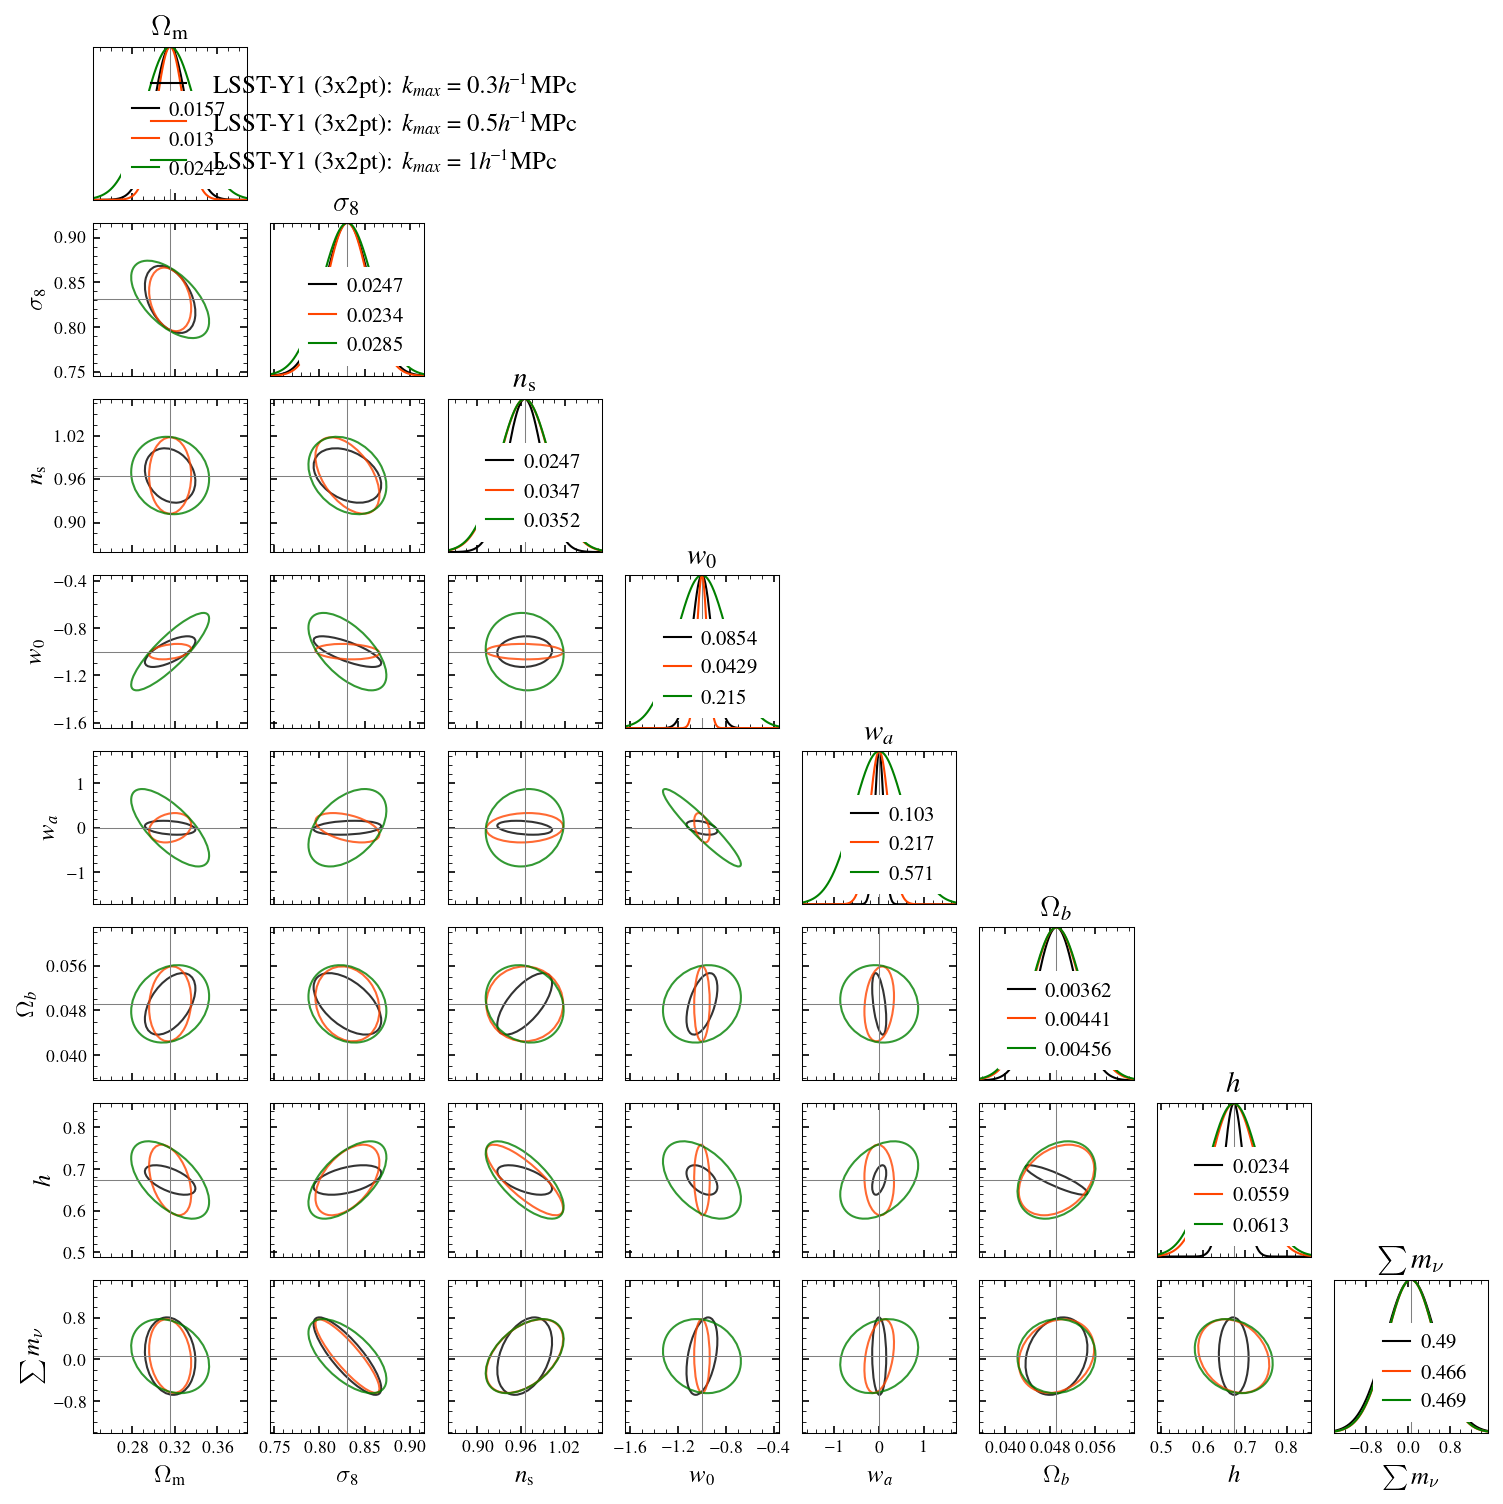

In [38]:
lsst_fmat1 = np.load('results/lsst_3x2pt_kmax0.3.npy', allow_pickle=True).item()['fmat']
lsst_fmat2 = np.load('results/lsst_3x2pt_kmax0.5.npy', allow_pickle=True).item()['fmat']
lsst_fmat3 = np.load('results/lsst_3x2pt_kmax1.npy', allow_pickle=True).item()['fmat']
print(np.sum(lsst_fmat1), np.sum(lsst_fmat2))

#Plot constraints
lsst_cosmo_params = ['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h', 'mnu']
##lsst_param_dict_more = {'omega_m': 0.3156, 'omega_b': 0.0491685, 'sigma_8': 0.831, 'a_0': 5.92, 'beta': 1.1, 'eta_low_z': -0.47, 'eta_high_z': 0.0, 'b_1': 1.2509509, 'b_2': 1.37274743, 'b_3': 1.50062059, 'b_4': 1.64802316, 'b_5': 1.7995586, 'phi_0_star': 0.0111, 'p': -1.15, 'm_0_star': -20.34, 'q': 1.2, 'alpha': -0.57}

lsst_prior_dic = {'omegam': 0.15, 
                'sigma8': 0.2, 
                'ns': 0.1, 
                'w0': 0.5, 
                'wa': 1.3, 
                'omegab': 0.005, 
                'h': 0.125, 
                'b_1': 0.9, 
                'b_2': 0.9, 
                'b_3': 0.9, 
                'b_4': 0.9, 
                'b_5': 0.9, 
                'a_0': 2.5, 
                'beta': 1, 
                'eta_low_z': 1.5, 
                'eta_high_z': 0.5,
                'a_ia': 2.5,
                'eta_ia': 1.5,                  
                }

lsst_fmat1_with_prior = misc.add_prior(np.copy(lsst_fmat1), lsst_params_sr, lsst_prior_dic)
lsst_fmat2_with_prior = misc.add_prior(np.copy(lsst_fmat2), lsst_params_sr, lsst_prior_dic)
lsst_fmat3_with_prior = misc.add_prior(np.copy(lsst_fmat3), lsst_params_sr, lsst_prior_dic)

desired_params_to_plot = lsst_cosmo_params ##lsst_params_sr ##lsst_cosmo_params
fisher_mat_dic = {'lsst_fmat1': lsst_fmat1_with_prior, 
                  'lsst_fmat2': lsst_fmat2_with_prior, 
                  'lsst_fmat3': lsst_fmat3_with_prior, 
                }
color_dic = {'lsst_fmat1': 'black', 'lsst_fmat2': 'orangered', 'lsst_fmat3': 'green'}
label_dic = {'lsst_fmat1': r'LSST-Y1 (3x2pt): $k_{max} = 0.3 h^{-1}$MPc',
             'lsst_fmat2': r'LSST-Y1 (3x2pt): $k_{max} = 0.5 h^{-1}$MPc',
             'lsst_fmat3': r'LSST-Y1 (3x2pt): $k_{max} = 1 h^{-1}$MPc',
             }
         
fix_axis_range_to_xxsigma = 3 ##3 ##10 ##None #3
fsval = 12

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_mat_dic, tr, tc, lsst_params_sr, lsst_param_dict_sr, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
if len(desired_params_to_plot)>=3:
    ax = subplot(tr, tc, 3)
elif len(desired_params_to_plot)==2:
    ax = subplot(tr, tc, 2)
else:
    ax = subplot(tr, tc, 1)
for keyname in fisher_mat_dic:
    plot([], [], color = color_dic[keyname], label = r'%s' %(label_dic[keyname]))

legend(loc = 1, fontsize = fsval, framealpha = 0.)
axis('off')


# Including CMB lensing

In [208]:
# Obtain own data vectors for LSST
ell, zbin_arr_withkappa, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, data_vector_dic_withkappa, noise_vector_dic_withkappa, full_cov_mat_dic_withkappa = tools_nx2pt.get_nx2pt_data_vectors_and_cov(experiment, zbinwidth, ell = ell, cosmo_param_dict = lsst_param_dict_sr, get_cmb_lensing = True, obtain_cov = True, fsky_dic = lsst_fsky_dic)
##ell, zbin_arr_withkappa, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, data_vector_dic_withkappa, noise_vector_dic_withkappa = tools_nx2pt.get_nx2pt_data_vectors_and_cov(experiment, zbinwidth, ell = ell, cosmo_param_dict = lsst_param_dict_sr, get_cmb_lensing = True)
##full_cov_mat_dic_withkappa = tools_nx2pt.get_nx2t_cov(ell, data_vector_dic_withkappa, noise_vector_dic_withkappa, zbin_arr_sr, lsst_fsky_dic)

if (0):
    import scipy.linalg
    ellind_to_plot = 2 #18 #0
    to_plot = np.copy( full_cov_mat_dic_withkappa[ellind_to_plot] )
    full_inv_cov_mat = linalg.pinv(to_plot)
    ##print(full_inv_cov_mat.shape)
    to_plot[to_plot==0.] = None
    
    imshow(to_plot); colorbar(); show()

    to_plot = np.copy(full_inv_cov_mat)
    to_plot[to_plot==0.] = None
    imshow(to_plot); colorbar(); show()
    sys.exit()

#get derivatives
print('\n#get derivatives\n')
derivative_vector_dic_withkappa = tools_nx2pt.get_nx2pt_derivatives(experiment, zbinwidth, lsst_params_sr, lsst_param_dict_sr, dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, ell = ell, data_vector_dic = data_vector_dic_withkappa, get_cmb_lensing = True)

print('\nDone')

#get dN/dz
#data vector dict
#get cov

#get derivatives

omegam 0.3156 0.312444 0.318756
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
sigma8 0.831 0.8226899999999999 0.83931
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
ns 0.9649 0.955251 0.974549
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
w0 -1.0 -0.99 -1.01
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
wa 0.0 -0.01 0.01
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
omegab 0.0491685 0.048676815 0.049660184999999996
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
h 0.6736 0.666864 0.6803359999999999
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
mnu 0.06 0.059399999999999994 0.0606
#get dN/dz
#data vector dict
#get dN/dz
#data vector dict
b_1 1.2509509 1.238441391 1.2634604090000001
b_2 1.37274743 1.3590199557 1.3864749043
b_3 1.50062059 1.4856143841 1.5156267959
b_4 1.64802316 1.6315429284 1.6645033915999998
b_5 1.7995586 1.7815630139999998 1.81755418

In [209]:
#get Fisher matrix
obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s', 'cl_k_s', 'cl_k_g', 'cl_k_k']
lsst_fisher_mat_withkappa = tools_nx2pt.get_nx2pt_fisher(ell, lsst_params_sr, derivative_vector_dic_withkappa, obs_key_arr, full_cov_mat_dic_withkappa)
print(np.sum(lsst_fisher_mat_withkappa))


190614197.97333488


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 960x720 with 0 Axes>

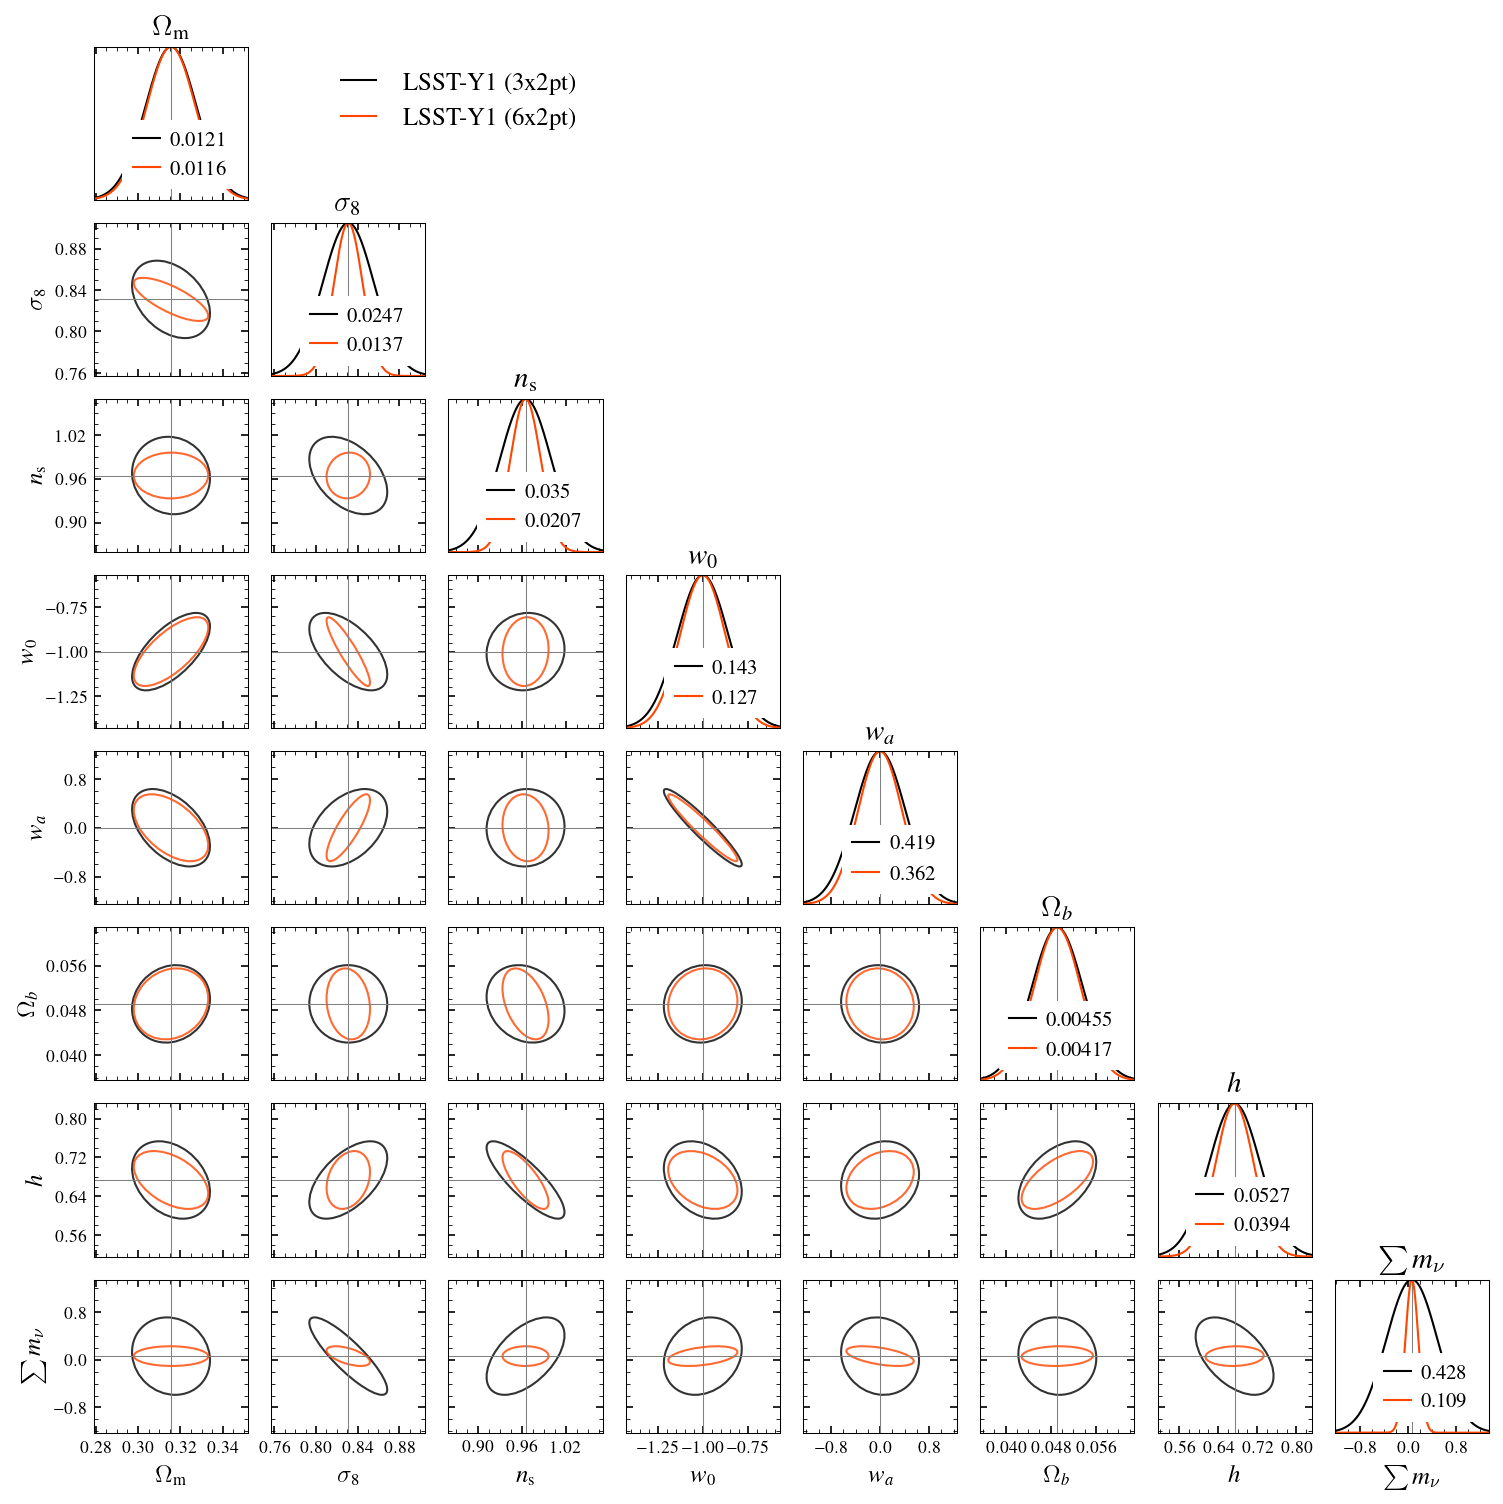

In [210]:
#Plot constraints
lsst_fisher_mat_sr_with_prior = misc.add_prior(np.copy(lsst_fisher_mat_sr), lsst_params_sr, lsst_prior_dic)
lsst_fisher_mat_withkappa_with_prior = misc.add_prior(np.copy(lsst_fisher_mat_withkappa), lsst_params_sr, lsst_prior_dic)

desired_params_to_plot = lsst_cosmo_params ##lsst_params_sr ##lsst_cosmo_params
fisher_mat_dic = {'lsst_fisher_mat_sr': lsst_fisher_mat_sr_with_prior, 
                  'lsst_fisher_mat_withkappa_with_prior': lsst_fisher_mat_withkappa_with_prior,
                }
color_dic = {'lsst_fisher_mat_sr': 'black', 'lsst_fisher_mat_withkappa_with_prior': 'orangered'}
label_dic = {'lsst_fisher_mat_sr': r'LSST-Y1 (3x2pt)',
             'lsst_fisher_mat_withkappa_with_prior': r'LSST-Y1 (6x2pt)',
             }
         
fix_axis_range_to_xxsigma = 3 ##3 ##10 ##None #3
fsval = 12

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_mat_dic, tr, tc, lsst_params_sr, lsst_param_dict_sr, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
if len(desired_params_to_plot)>=3:
    ax = subplot(tr, tc, 3)
elif len(desired_params_to_plot)==2:
    ax = subplot(tr, tc, 2)
else:
    ax = subplot(tr, tc, 1)
for keyname in fisher_mat_dic:
    plot([], [], color = color_dic[keyname], label = r'%s' %(label_dic[keyname]))

legend(loc = 1, fontsize = fsval, framealpha = 0.)
axis('off')


In [38]:
#get data vectors, derivative, and cov
#data vector
ell, zbin_arr, data_vector_dic, full_cov_mat_dic = tools_nx2pt.get_3x2pt_lsst_data(which_year = lsst_year, data_or_dervitive = 'data', obtain_cov = True, lsst_fsky_dic = lsst_fsky_dic)

lsst_param_mapping_dic = {'sigma8': 'sigma_8', 'omegam': 'omega_m', 'omegab': 'omega_b', 'w0': 'w_0', 'wa': 'w_a', 'ns': 'n_s'}
#derivative
derivative_dic = {}
for lsst_param in lsst_params:
    if lsst_param in lsst_param_mapping_dic:
        lsst_param_for_deriv = lsst_param_mapping_dic[lsst_param]
    else:
        lsst_param_for_deriv = lsst_param
    ell, zbin_arr, curr_deriv_vector_dic = tools_nx2pt.get_3x2pt_lsst_data(which_year = lsst_year, data_or_dervitive = 'derivative', param_for_derivative = lsst_param_for_deriv)
    derivative_dic[lsst_param] = curr_deriv_vector_dic

#get cov
#full_cov_mat_dic = tools_nx2pt.get_nx2t_cov(ell, data_vector_dic, zbin_arr, lsst_fsky_dic)
##print(full_cov_mat_dic.keys())

#get Fisher matrix
obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s']
lsst_fisher_mat = tools_nx2pt.get_nx2pt_fisher(ell, lsst_params, derivative_dic, obs_key_arr, full_cov_mat_dic)
print(np.sum(lsst_fisher_mat))


3214571.2722119857


['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h']


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 960x720 with 0 Axes>

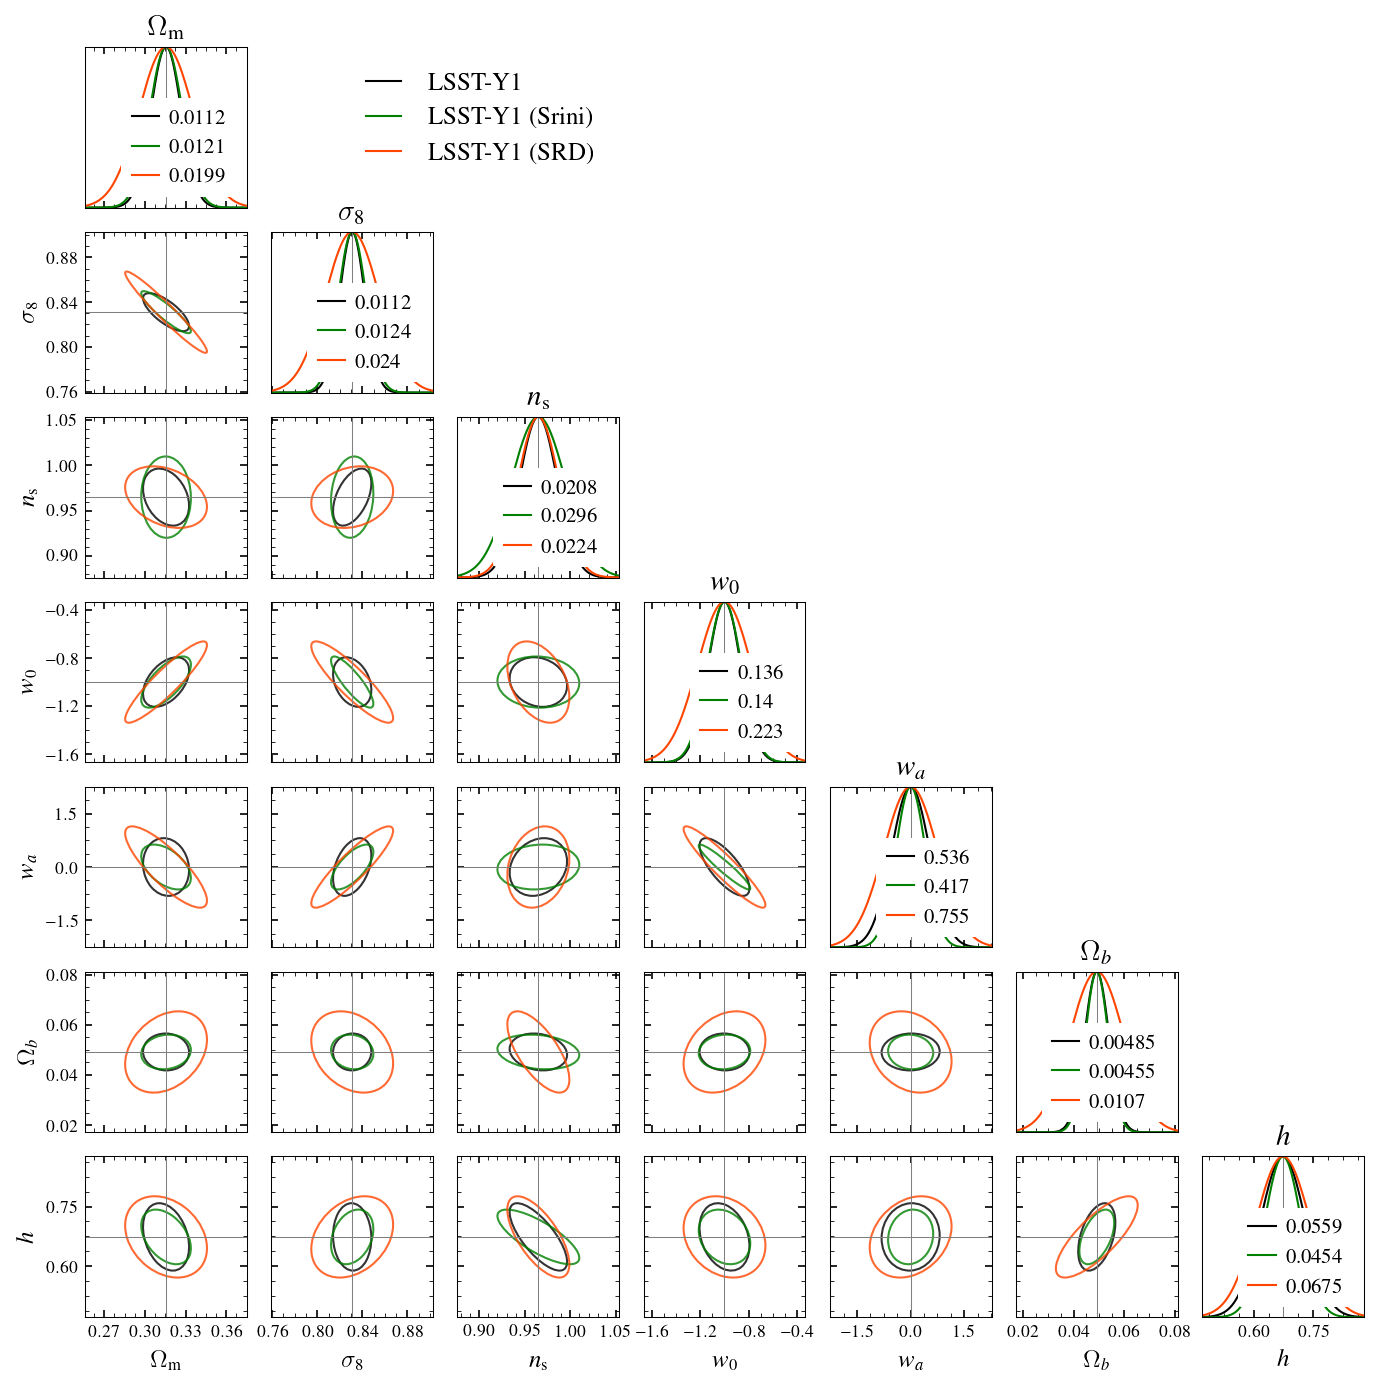

In [50]:
#Plot constraints
lsst_cosmo_params = ['omegam', 'sigma8', 'ns', 'w0', 'wa', 'omegab', 'h']
#lsst_param_dict_more = {'omega_m': 0.3156, 'omega_b': 0.0491685, 'sigma_8': 0.831, 'a_0': 5.92, 'beta': 1.1, 'eta_low_z': -0.47, 'eta_high_z': 0.0, 'b_1': 1.2509509, 'b_2': 1.37274743, 'b_3': 1.50062059, 'b_4': 1.64802316, 'b_5': 1.7995586, 'phi_0_star': 0.0111, 'p': -1.15, 'm_0_star': -20.34, 'q': 1.2, 'alpha': -0.57}

lsst_prior_dic = {'omegam': 0.15, 
                'sigma8': 0.2, 
                'ns': 0.1, 
                'w0': 0.5, 
                'wa': 1.3, 
                'omegab': 0.005, 
                'h': 0.125, 
                'b_1': 0.9, 
                'b_2': 0.9, 
                'b_3': 0.9, 
                'b_4': 0.9, 
                'b_5': 0.9, 
                'a_0': 2.5, 
                'beta': 1, 
                'eta_low_z': 1.5, 
                'eta_high_z': 0.5,
                'a_ia': 2.5,
                'eta_ia': 1.5,                  
                }

lsst_fisher_mat_with_prior = misc.add_prior(np.copy(lsst_fisher_mat), lsst_params, lsst_prior_dic)

lsst_fisher_mat_srd_fname = 'data/LSST_3x2pt/srd_comsology/fisher_matrices/cmb_y1_3x2pt_fisher_matrix_all_priors.npy'
lsst_fisher_mat_srd = np.load(lsst_fisher_mat_srd_fname, allow_pickle=True)

desired_params_to_plot = lsst_cosmo_params ##lsst_cosmo_params
fisher_mat_dic = {'lsst_fisher_mat': lsst_fisher_mat_with_prior, 
                  'lsst_fisher_mat_sr': lsst_fisher_mat_sr_with_prior, 
                  'lsst_fisher_mat_srd': lsst_fisher_mat_srd,
                }
color_dic = {'lsst_fisher_mat': 'black', 'lsst_fisher_mat_sr': 'green', 'lsst_fisher_mat_srd': 'orangered'}
label_dic = {'lsst_fisher_mat': r'LSST-Y1',
             'lsst_fisher_mat_srd': r'LSST-Y1 (SRD)',
             'lsst_fisher_mat_sr': r'LSST-Y1 (Srini)',
             }
         
fix_axis_range_to_xxsigma = 3 ##3 ##10 ##None #3
fsval = 12

print(lsst_cosmo_params)

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_mat_dic, tr, tc, lsst_params, lsst_param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
if len(desired_params_to_plot)>=3:
    ax = subplot(tr, tc, 3)
elif len(desired_params_to_plot)==2:
    ax = subplot(tr, tc, 2)
else:
    ax = subplot(tr, tc, 1)
for keyname in fisher_mat_dic:
    plot([], [], color = color_dic[keyname], label = r'%s' %(label_dic[keyname]))

legend(loc = 1, fontsize = fsval, framealpha = 0.)
axis('off')


In [220]:
#get data vectors, derivative, and cov
#data vector
ell, zbin_arr, data_vector_dic, full_cov_mat_dic = tools_nx2pt.get_3x2pt_lsst_data(which_year = lsst_year, data_or_dervitive = 'data', obtain_cov = True, lsst_fsky_dic = lsst_fsky_dic)

#derivative
derivative_dic = {}
for lsst_param in lsst_params:
    ell, zbin_arr, curr_deriv_vector_dic = tools_nx2pt.get_3x2pt_lsst_data(which_year = lsst_year, data_or_dervitive = 'derivative', param_for_derivative = lsst_param)
    derivative_dic[lsst_param] = curr_deriv_vector_dic

#get cov
#full_cov_mat_dic = tools_nx2pt.get_nx2t_cov(ell, data_vector_dic, zbin_arr, lsst_fsky_dic)
##print(full_cov_mat_dic.keys())

#get Fisher matrix
obs_key_arr = ['cl_s_s', 'cl_g_g', 'cl_g_s']
lsst_fisher_mat = tools_nx2pt.get_nx2pt_fisher(ell, lsst_params, derivative_dic, obs_key_arr, full_cov_mat_dic)
print(np.sum(lsst_fisher_mat))


3214571.2722119857


(-0.05500000000000001,
 0.05500000000000001,
 -0.05500000000000001,
 0.05500000000000001)

<Figure size 960x720 with 0 Axes>

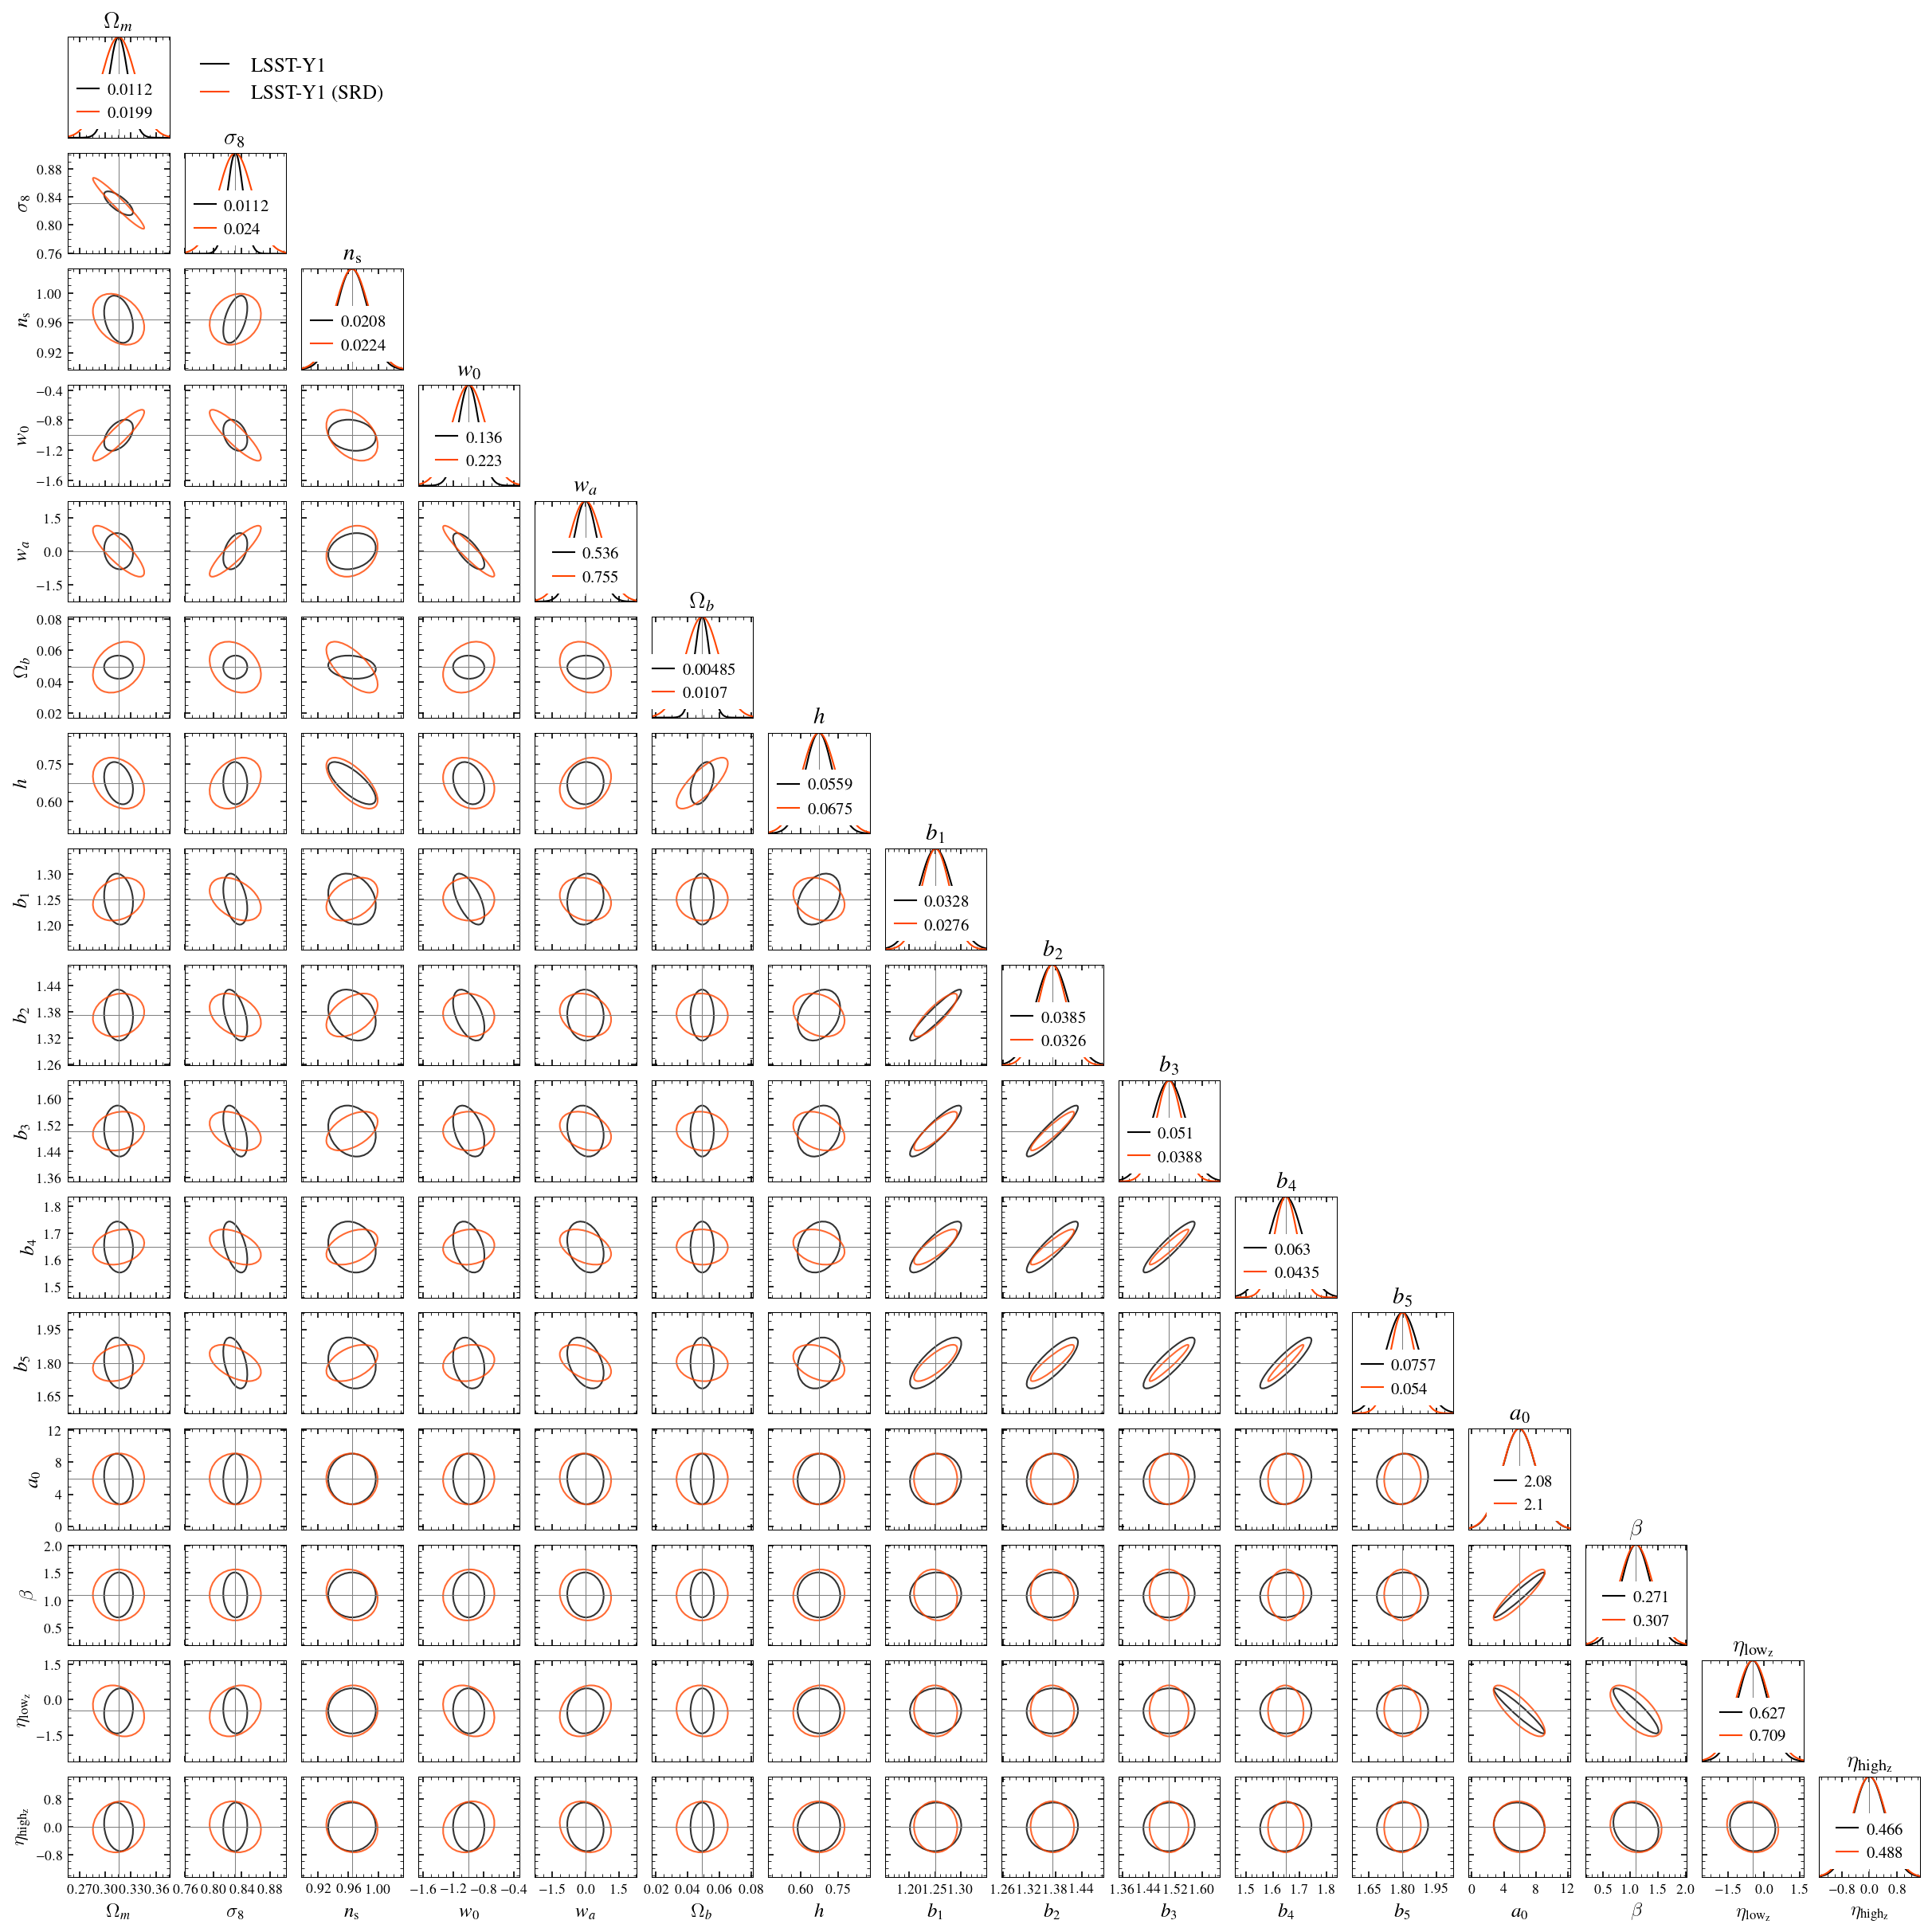

In [221]:
#Plot constraints
lsst_cosmo_params = ['omega_m', 'sigma_8', 'n_s', 'w_0', 'w_a', 'omega_b', 'h']
lsst_param_dict_more = {'omega_m': 0.3156, 'omega_b': 0.0491685, 'sigma_8': 0.831, 'a_0': 5.92, 'beta': 1.1, 'eta_low_z': -0.47, 'eta_high_z': 0.0, 'b_1': 1.2509509, 'b_2': 1.37274743, 'b_3': 1.50062059, 'b_4': 1.64802316, 'b_5': 1.7995586, 'phi_0_star': 0.0111, 'p': -1.15, 'm_0_star': -20.34, 'q': 1.2, 'alpha': -0.57}

lsst_prior_dic = {'omega_m': 0.15, 
                'sigma_8': 0.2, 
                'n_s': 0.1, 
                'w_0': 0.5, 
                'w_a': 1.3, 
                'omega_b': 0.005, 
                'h': 0.125, 
                'b_1': 0.9, 
                'b_2': 0.9, 
                'b_3': 0.9, 
                'b_4': 0.9, 
                'b_5': 0.9, 
                'a_0': 2.5, 
                'beta': 1, 
                'eta_low_z': 1.5, 
                'eta_high_z': 0.5,
                }

lsst_fisher_mat_with_prior = misc.add_prior(np.copy(lsst_fisher_mat), lsst_params, lsst_prior_dic)

lsst_fisher_mat_srd_fname = 'data/LSST_3x2pt/srd_comsology/fisher_matrices/cmb_y1_3x2pt_fisher_matrix_all_priors.npy'
lsst_fisher_mat_srd = np.load(lsst_fisher_mat_srd_fname, allow_pickle=True)

desired_params_to_plot = lsst_params ##lsst_cosmo_params
fisher_mat_dic = {'lsst_fisher_mat': lsst_fisher_mat_with_prior, 
                  'lsst_fisher_mat_srd': lsst_fisher_mat_srd,
                }
color_dic = {'lsst_fisher_mat': 'black', 'lsst_fisher_mat_srd': 'orangered'}
label_dic = {'lsst_fisher_mat': r'LSST-Y1',
             'lsst_fisher_mat_srd': r'LSST-Y1 (SRD)',
             }
         
fix_axis_range_to_xxsigma = 3 ##3 ##10 ##None #3
fsval = 12

clf()
tr, tc = len( desired_params_to_plot ), len( desired_params_to_plot )
figure(figsize = (tr+4, tc+4))
subplots_adjust(hspace=0.15, wspace = 0.15)
color_dic, ls_dic = misc.make_triangle_plot(fisher_mat_dic, tr, tc, lsst_params, lsst_param_dict, desired_params_to_plot, fsval = fsval, color_dic = color_dic, fix_axis_range_to_xxsigma = fix_axis_range_to_xxsigma, ncol = 1)#, one_or_two_sigma = 1, fsval = 12, noofticks = 4)

#legend
if len(desired_params_to_plot)>=3:
    ax = subplot(tr, tc, 3)
elif len(desired_params_to_plot)==2:
    ax = subplot(tr, tc, 2)
else:
    ax = subplot(tr, tc, 1)
for keyname in fisher_mat_dic:
    plot([], [], color = color_dic[keyname], label = r'%s' %(label_dic[keyname]))

legend(loc = 1, fontsize = fsval, framealpha = 0.)
axis('off')


In [68]:
#get data vectors
ell, zbin_arr, data_vector_dic = tools_nx2pt.get_3x2pt_lsst_data()

#get cov
tools_nx2pt.get_nx2t_cov(ell, data_vector_dic, zbin_arr)


[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (1, 1), (1, 2), (1, 3), (1, 4), (2, 2), (2, 3), (2, 4), (3, 3), (3, 4), (4, 4)]
[(0, 0), (1, 1), (2, 2), (3, 3), (4, 4)]
[(0, 1), (0, 2), (0, 3), (0, 4), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4), (4, 4)]
[2.38055304e-09 1.62227349e-09 1.07305296e-09 7.06698649e-10
 4.71234283e-10 3.19858791e-10 2.20759258e-10 1.53012929e-10
 1.04682930e-10 6.94939592e-11 4.41711279e-11 2.66681907e-11
 1.52626333e-11 8.31111358e-12 4.34020124e-12 2.19479845e-12
 1.08518646e-12 5.29240789e-13 2.56490110e-13 1.24115706e-13]


SystemExit: 

In [73]:
2.38055304e-09 * 2.38055304e-09

5.6670327762532414e-18

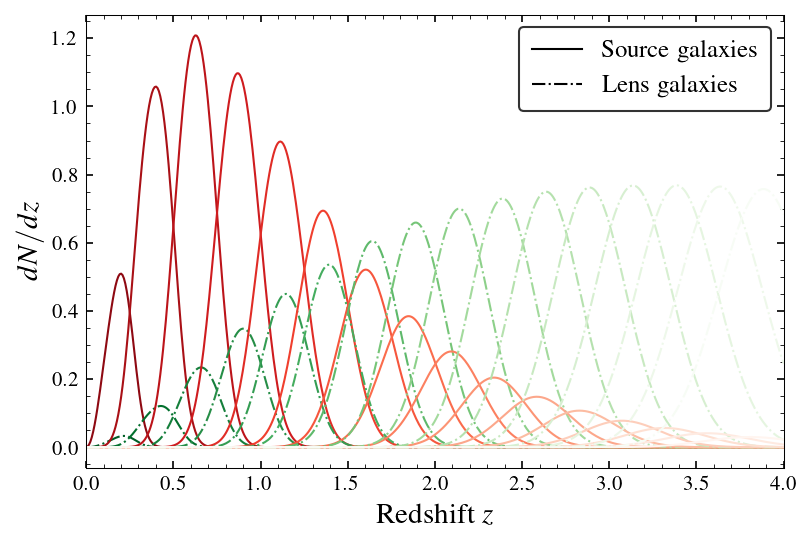

In [6]:
clf()
fsval = 14
#experiment = 'euclid_spec'
experiment = 'roman_hls'
#zbin_arr = [0.21, 0.49, 0.62, 0.73, 0.84, 0.96, 1.09, 1.24, 1.45, 2.04]
#zbin_arr = [0.84, 0.96, 1.09, 1.24, 1.45, 2.04]
zbinwidth = 0.2
zbin_arr = [(z, z+zbinwidth) for z in np.arange(0., 4., zbinwidth)]

if (1):
    zbinwidth = 0.25
    zbin_arr = [(z, z+zbinwidth) for z in np.arange(0., 4., zbinwidth)]
    

color_arr = [cm.Reds_r(int(d)) for d in np.linspace(20, 255, len(zbin_arr))]
color_arr_v2 = [cm.Greens_r(int(d)) for d in np.linspace(20, 255, len(zbin_arr))]
dndz_lensgalsforclus_dic = {}
dndz_sourcegalsforshear_dic = {}
zbin_mid_arr = []
for cntr, zbin in enumerate( zbin_arr ):
    zbin_mid = (zbin[0] + zbin[1] )/2.
    zarr_source, dndz_bin_source, bias_source = tools_nx2pt.get_dngal_dz_photoz('%s_source' %(experiment), zbin)
    dndz_lensgalsforclus_dic[zbin_mid] = [zarr_source, dndz_bin_source, bias_source]
    zarr_lens, dndz_bin_lens, bias_lens = tools_nx2pt.get_dngal_dz_photoz('%s_lens' %(experiment), zbin)
    dndz_sourcegalsforshear_dic[zbin_mid] = [zarr_lens, dndz_bin_lens, bias_lens]
    plot( zarr_source, dndz_bin_source, color = color_arr[cntr])
    plot( zarr_lens, dndz_bin_lens, color = color_arr_v2[cntr], ls = '-.')
    zbin_mid_arr.append( zbin_mid )
xlim(0., 4.)
plot([], [], 'k-', label = r'Source galaxies')
plot([], [], 'k-.', label = r'Lens galaxies')
xlabel(r'Redshift $z$', fontsize = fsval)
ylabel(r'$dN/dz$', fontsize = fsval)
legend(loc = 1, fontsize = fsval-2)
show()

# Obtain data vectors

In [194]:
ell = np.geomspace(2, 1000, 10)
data_vector_dic = tools_nx2pt.get_nx2pt_data_vectors_and_cov(dndz_lensgalsforclus_dic, dndz_sourcegalsforshear_dic, ell = ell)

In [ ]:
#get cov
total_observables = 3
total_zbins = len( zbin_mid_arr )
total_ellbins = len(ell)
cov_mat_ndim = (total_observables-1) * total_zbins + 1

for elcntr, elval in enumerate( ell ):
    full_cov_mat = np.zeros( (cov_mat_ndim, cov_mat_ndim) )

    #diagonals
    for obscntr, obs_key in enumerate( ['cl_g_g', 'cl_s_s'] ):
        curr_cov_mat = np.zeros( (total_zbins, total_zbins) )
        for z1cntr, z1 in enumerate( zbin_mid_arr ):
            for z2cntr, z2 in enumerate( zbin_mid_arr ):
                curr_data_val = data_vector_dic[obs_key][(z1,z2)][elcntr]
                curr_cov_mat[(z1cntr, z2cntr)] = curr_data_val**2.
        s = obscntr * total_zbins
        e = s + total_zbins
        full_cov_mat[s:e, s:e] = curr_cov_mat
        ##print(curr_cov_mat)


    #off-diagonals
    for obscntr, obs_key in enumerate( ['cl_g_s'] ):
        curr_cov_mat = np.zeros( (total_zbins, total_zbins) )
        for z1cntr, z1 in enumerate( zbin_mid_arr ):
            for z2cntr, z2 in enumerate( zbin_mid_arr ):
                curr_data_val = data_vector_dic[obs_key][(z1,z2)][elcntr]
                curr_cov_mat[(z1cntr, z2cntr)] = curr_data_val**2.
        s = total_zbins
        e = s + total_zbins
        ##print(curr_cov_mat)
        full_cov_mat[s:e, 0:s] = curr_cov_mat
        full_cov_mat[0:s, s:e] = curr_cov_mat

    #CMB-lensing cross
    
    
    #corr mat
    full_corr_mat = tools_nx2pt.corr_from_cov(full_cov_mat)

    
    imshow(full_cov_mat); colorbar(); show()
    sys.exit()

In [34]:
import pyccl as ccl
import numpy as np

# 1. Initialize Cosmology
cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=0.67, sigma8=0.81, n_s=0.96)

# 2. Define Tracers (Redshift distributions n(z) and bias)
# CMB lensing
t_cmb = ccl.CMBLensingTracer(cosmo, z_source=1100.)

if (1):
    color_arr = [cm.RdYlBu_r(int(d)) for d in np.linspace(0, 255, len(zbin_arr))]
    clf()
    cl_dic = {}
    for cntr, zbin in enumerate( zbin_arr ):
        print(cntr)
        zarr, dndz_bin = tools_nx2pt.get_dngal_dz_photoz(experiment, zbin)
        z1, z2 = zbin
        bias_model = (1+zarr)*1.2
        """
        if (0):##z2<=0.8:
            bias_model = 1.5
        else:
            bias_model = (1+zarr)**2.
        """
        print(bias_model)
        plot(zarr, bias_model, color = color_arr[cntr])
        curr_t_g = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(zarr, dndz_bin), 
                                     bias=(zarr, bias_model))
    
        # 3. Define Angular Scales
        ell = np.geomspace(2, 2000, 20)
        
        # 4. Compute a Gaussian Covariance Block
        # This calculates Cov(Cl_gs, Cl_gs) for a given sky fraction
        curr_cl_g_g = ccl.angular_cl(
            cosmo,
            curr_t_g, curr_t_g,
            ell=ell,
        )
        curr_cl_kappa_g = ccl.angular_cl(
            cosmo,
            t_cmb, curr_t_g,
            ell=ell,
        )
        cl_dic[cntr] = [ell, curr_cl_g_g, curr_cl_kappa_g]
    show()
clf()
for cntr, zbin in enumerate( zbin_arr ):
    ell, curr_cl_g_g, curr_cl_kappa_g = cl_dic[cntr]
    plot(ell, curr_cl_g_g, color = color_arr[cntr])
    #plot(ell, curr_cl_kappa_g, color = color_arr[cntr], ls = '--')
show()

SystemExit: 

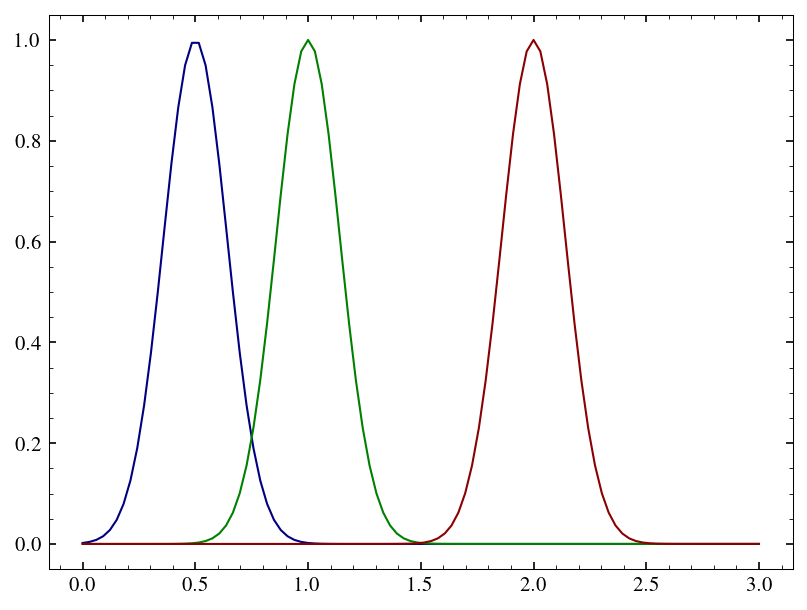

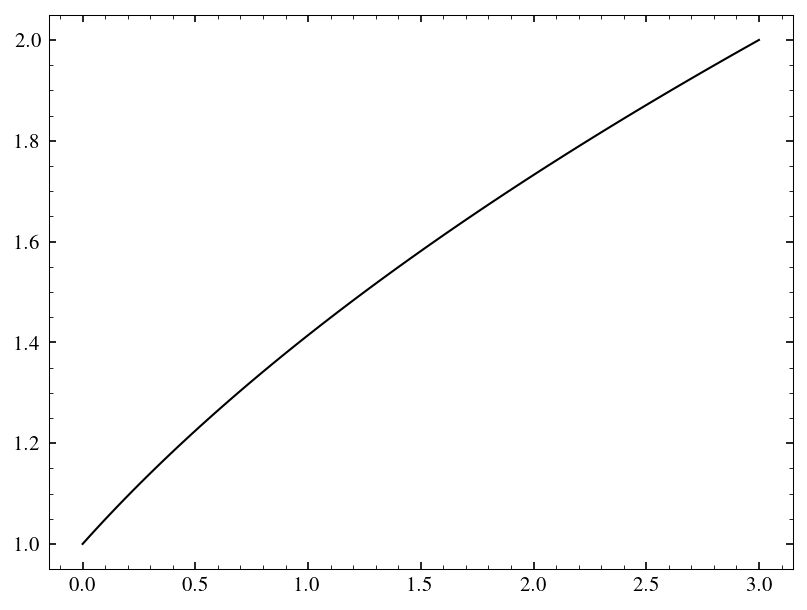

In [35]:
import pyccl as ccl
import numpy as np

# 1. Initialize Cosmology
cosmo = ccl.Cosmology(
    Omega_c=0.27, Omega_b=0.045, h=0.67, sigma8=0.81, n_s=0.96)

# 2. Define Tracers (Redshift distributions n(z) and bias)
z = np.linspace(0., 3., 100)
nz_lens = np.exp(-((z-0.5)/0.1)**2)   # Lens galaxies (Clustering)
nz_source = np.exp(-((z-1.0)/0.2)**2) # Source galaxies (Shear)

nz_lens_lowz = np.exp(-((z-0.5)/0.2)**2) # Low-z Lens galaxies (Clustering)
nz_lens_midz = np.exp(-((z-1.0)/0.2)**2) # Mid-z Lens galaxies (Clustering)
nz_lens_highz = np.exp(-((z-2.0)/0.2)**2) # High-z Lens galaxies (Clustering)

clf()
#plot(z, nz_lens)
#plot(z, nz_source)
plot(z, nz_lens_lowz, color = 'navy')
plot(z, nz_lens_midz, color = 'green')
plot(z, nz_lens_highz, color = 'darkred')
show()

bias_model = np.ones_like(z)*1.2
bias_model = np.sqrt(1+z)
# NumberCounts = Galaxy Clustering Tracer
t_g = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, nz_lens), 
                             bias=(z, bias_model))

t_lowzg = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, nz_lens_lowz), 
                             bias=(z, bias_model))

t_midzg = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, nz_lens_midz), 
                             bias=(z, bias_model))

t_highzg = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, nz_lens_highz), 
                             bias=(z, bias_model))

clf()
plot(z, bias_model)
show()

# WeakLensing = Cosmic Shear Tracer
t_s = ccl.WeakLensingTracer(cosmo, dndz=(z, nz_source))

# CMB lensing
t_cmb = ccl.CMBLensingTracer(cosmo, z_source=1100.)

# 3. Define Angular Scales
ell = np.geomspace(2, 2000, 20)

# 4. Compute a Gaussian Covariance Block
# This calculates Cov(Cl_gs, Cl_gs) for a given sky fraction
fsky = 0.1  # 10% of the sky
cl_gg = ccl.angular_cl(
    cosmo,
    t_g,
    t_s,
    ell=ell,
)
cl_ss = ccl.angular_cl(
    cosmo,
    t_s,
    t_s,
    ell=ell,
)
cl_gs = ccl.angular_cl(
    cosmo,
    t_s,
    t_g,
    ell=ell,
)
cl_kappakappa = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_cmb,
    ell=ell,
)
cl_kappas = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_s,
    ell=ell,
)
cl_kappag = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_g,
    ell=ell,
)

cl_kappalowzg = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_lowzg,
    ell=ell,
)
cl_kappamidzg = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_midzg,
    ell=ell,
)

cl_kappahighzg = ccl.angular_cl(
    cosmo,
    t_cmb,
    t_highzg,
    ell=ell,
)





In [37]:
t_cmb

<pyccl.tracers.Tracer>
	num       kernel             transfer       prefac  bessel 
	 0  0xc732f1e0500d330c         None           1       -1   

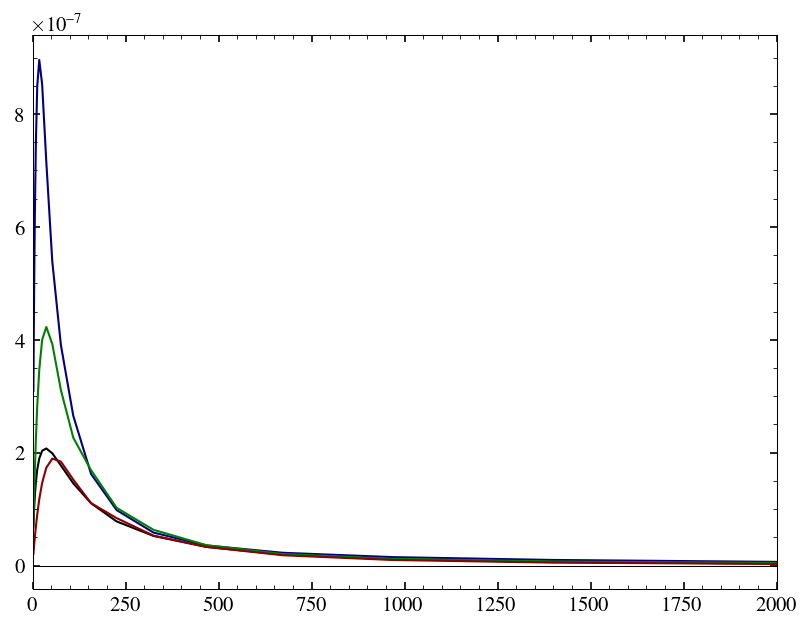

In [38]:
clf()
dl_fac = 1. ##ell * (ell+1)/2/np.pi
# plot(ell, cl_gg)
# plot(ell, cl_ss)
# plot(ell, cl_gs)
plot(ell, cl_kappakappa)
plot(ell, cl_kappalowzg, color = 'navy')
plot(ell, cl_kappamidzg, color = 'green')
plot(ell, cl_kappahighzg, color = 'darkred')
#plot(ell, cl_kappag)
#plot(ell, cl_kappas)
axhline(lw = 0.5)
xlim(0, 2000)
show()

# Check LSST data vectors

(27, 20)


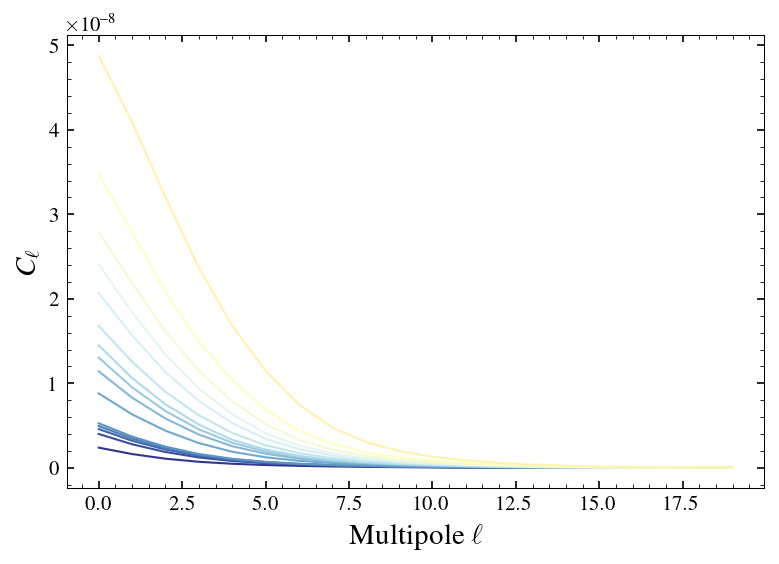

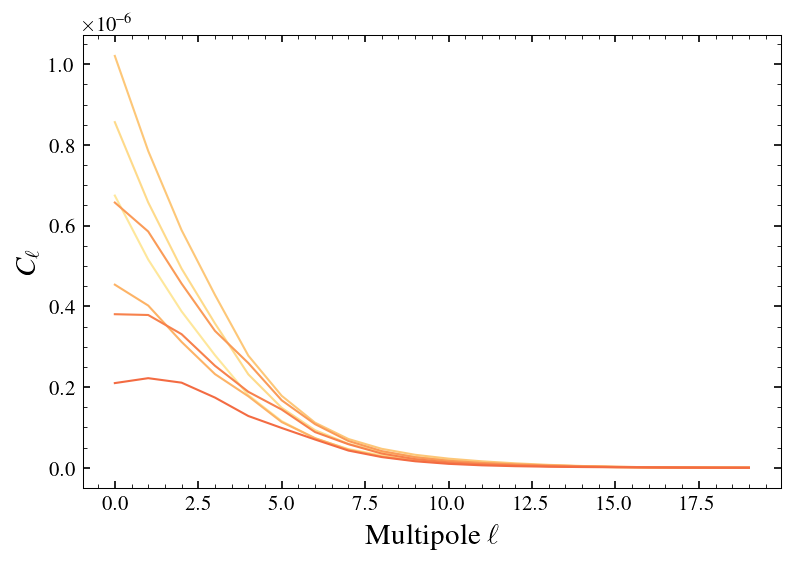

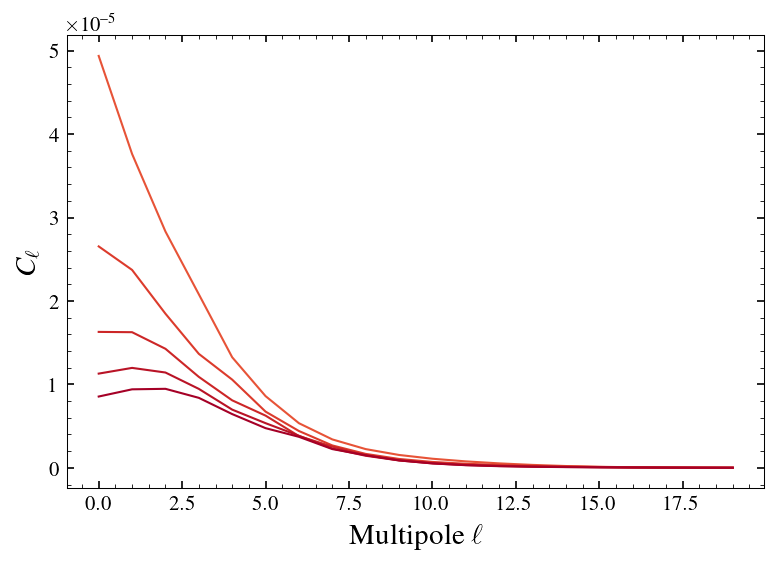

In [19]:
lsstfd = '/Users/sraghunathan/Research/SPTpol/analysis/git/CMB_SNIa_3x2pt_Fisher/data/LSST_3x2pt/srd_comsology/data_vectors/'
lsstfname = '%s/cmb_y1_3x2pt_data_vector_cosmo_priors.npy' %(lsstfd)
lsstdata = np.load( lsstfname, allow_pickle=True )
print( lsstdata.shape )

color_arr = [cm.RdYlBu_r(int(d)) for d in np.linspace(0, 255, 27)]
clf()
fsval = 14
for iii in range(15):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()

clf()
for iii in range(15, 22):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()


clf()
for iii in range(22, 27):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()


(27, 20)


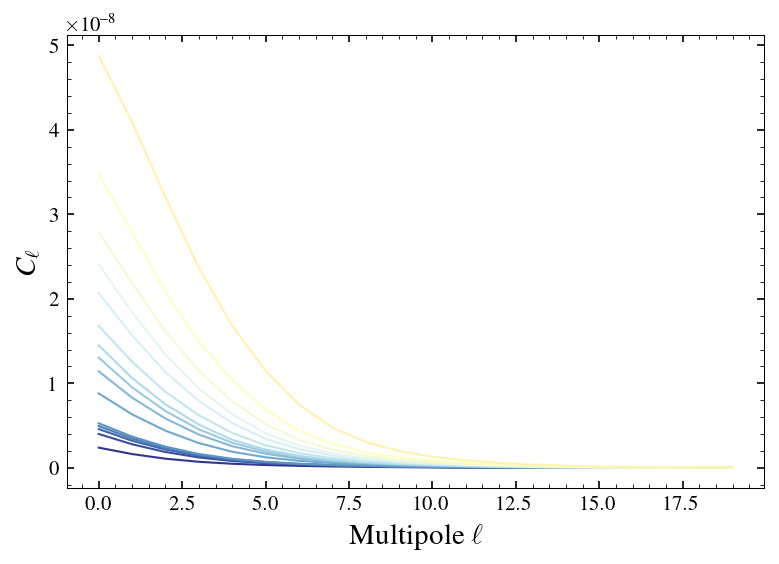

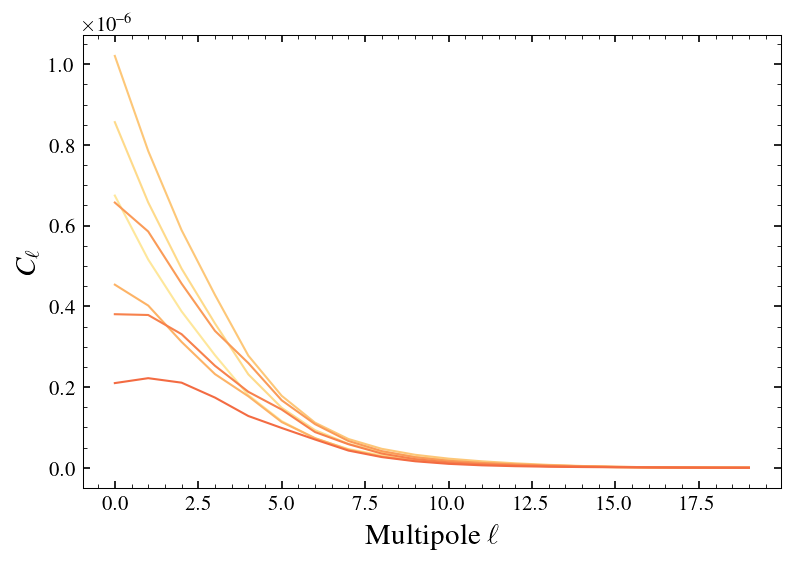

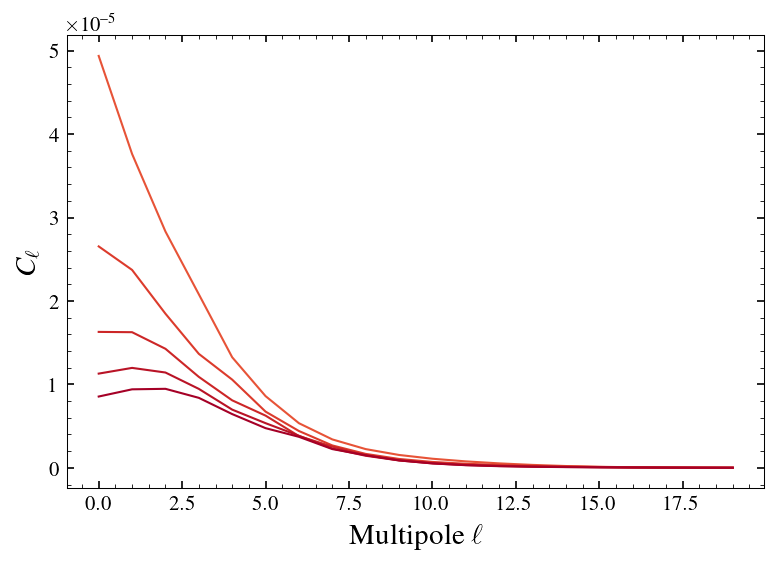

In [20]:
lsstfd = '/Users/sraghunathan/Research/SPTpol/analysis/git/CMB_SNIa_3x2pt_Fisher/data/LSST_3x2pt/srd_comsology/data_vectors/'
lsstfname = '%s/cmb_y1_3x2pt_data_vector_all_priors.npy' %(lsstfd)
lsstdata = np.load( lsstfname, allow_pickle=True )
print( lsstdata.shape )

color_arr = [cm.RdYlBu_r(int(d)) for d in np.linspace(0, 255, 27)]
clf()
fsval = 14
for iii in range(15):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()

clf()
for iii in range(15, 22):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()


clf()
for iii in range(22, 27):
    plot(lsstdata[iii], color = color_arr[iii])
xlabel(r'Multipole $\ell$', fontsize = fsval)
ylabel(r'$C_{\ell}$', fontsize = fsval)
show()
